In [1]:
# %%
import numpy as np
from matplotlib import pyplot as plt
import csv

# %matplotlib inline

import xarray as xr
import lib_ecofun as lef

from scipy.optimize import curve_fit, minimize, dual_annealing, basinhopping, brute, differential_evolution, shgo, direct


In [2]:
from importlib import reload
reload(lef)

<module 'lib_ecofun' from '/home/fedef/Research/abstractsepapers/papers/DREAM/codes/lib_ecofun.py'>

In [3]:
allobs = lef.define_obs(None, adimensional=True)

In [4]:
# %%
year_ini = 2000
params = lef.default_params.copy()

verbose = False

public_investment = False

params['r_inv_state'] = 0.015
arr = np.concatenate([np.linspace(0., 0.7, 20), np.linspace(0.7, 0.7, 80)])
mu_scen = xr.DataArray(arr, dims = ('year'), coords = {'year': np.arange(year_ini, year_ini + 100)})

obs_weights = None

result_dict = {}

In [5]:
params['a'] = 2.3
params['b'] = 1.4

In [6]:
params_prime = params.copy()

params_prime['a'] = lef.a_prime(year_ini, a = params['a'])
params_prime['b'] = lef.a_prime(year_ini, a = params['b'])

In [10]:
params_prime

{'growth': 0.01,
 'eps': 1,
 'a': 0.7061236460320618,
 'b': 0.4298143932369072,
 'gamma_f': 0.5,
 'gamma_g': 0.5,
 'eta_g': 0.2,
 'eta_f': 0.2,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.1,
 'beta_0': 0.2,
 'delta_sig': 0.5,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [7]:
params_prime_range = {
 'growth': (0.01, 0.05),
 'delta_sig': (0.2, 1.),
 'a': (0.6, 1.1),
 'b': (0.3, 0.8),
 'gamma_f': (0.1, 0.7),
 'gamma_g': (0.1, 0.7),
 'eta_g': (0.1, 0.95),
 'eta_f': (0.1, 0.95),
 'r_inv': (0.05, 0.5),
 'beta_0': (-0.5, 0.5)}

In [8]:
inicond = lef.inicond_yr(year_ini, params_prime, adimensional = True, fcu = lef.fossil_capacity_util)

In [11]:
inicond

{'Y_ini': 1.0,
 'Eg_ini': 0.07825325742181562,
 'Ef_ini': 0.9217467425781845,
 'E_ini': 1.0,
 'Kf_ini': 2.6806534316957236,
 'Kg_ini': 0.11082089923138264}

In [13]:
gdp_scen = lef.read_gdp_scenarios()

In [14]:
from scipy.optimize import curve_fit

def fit_piecewise(da: xr.DataArray, breakpoint_year: int = None) -> dict:
    """
    Fit a two-slope piecewise linear function with bias to a DataArray with 'year' dimension.
    
    f(year) = c + m1*(year - bp)        if year <= breakpoint
              c + m2*(year - bp)        if year >  breakpoint
    """
    years = da.year.values.astype(float)
    values = da.values.astype(float)
    
    if breakpoint_year is None:
        breakpoint_year = int(years[len(years) // 2])
    
    def model(year, m1, m2, c):
        return c + np.where(
            year <= breakpoint_year,
            m1 * (year - breakpoint_year),
            m2 * (year - breakpoint_year)
        )
    
    overall_slope = (values[-1] - values[0]) / (years[-1] - years[0])
    anchor = float(da.sel(year=breakpoint_year))
    p0 = [overall_slope, overall_slope, anchor]
    
    popt, pcov = curve_fit(model, years, values, p0=p0)
    m1, m2, c = popt
    
    fitted_values = model(years, m1, m2, c)
    fitted_da = xr.DataArray(fitted_values, coords={"year": da.year}, dims="year")
    
    return {
        "m1": m1,
        "m2": m2,
        "c": c,
        "breakpoint_year": breakpoint_year,
        "fitted": fitted_da,
        "perr": np.sqrt(np.diag(pcov))
    }

In [15]:
ok_gdp = lef.gdp.sel(year = slice(2000, None))

In [16]:
def model(year, m1, m2, c, breakpoint_year):
    return c + np.where(
        year <= breakpoint_year,
        m1 * (year - breakpoint_year),
        m2 * (year - breakpoint_year)
    )

In [113]:
fit_piecewise(ok_gdp, breakpoint_year= 2010)

{'m1': 3809.360024336776,
 'm2': 2313.15023071385,
 'c': 67996.21082255931,
 'breakpoint_year': 2010,
 'fitted': <xarray.DataArray (year: 23)>
 array([29902.61057919, 33711.97060353, 37521.33062787, 41330.6906522 ,
        45140.05067654, 48949.41070088, 52758.77072521, 56568.13074955,
        60377.49077389, 64186.85079822, 67996.21082256, 70309.36105327,
        72622.51128399, 74935.6615147 , 77248.81174541, 79561.96197613,
        81875.11220684, 84188.26243756, 86501.41266827, 88814.56289898,
        91127.7131297 , 93440.86336041, 95754.01359113])
 Coordinates:
   * year     (year) int64 2000 2001 2002 2003 2004 ... 2018 2019 2020 2021 2022,
 'perr': array([ 268.30325453,  217.56866647, 1425.44058184])}

In [17]:
spezzata = model(ok_gdp.year, 3809.4, 2313.15, c = 67996.2, breakpoint_year=2010)

gdp_fit = xr.DataArray(spezzata, coords={"year": ok_gdp.year}, dims="year")

In [18]:
gdp_fit

<xarray.DataArray (year: 23)>
array([29902.2 , 33711.6 , 37521.  , 41330.4 , 45139.8 , 48949.2 ,
       52758.6 , 56568.  , 60377.4 , 64186.8 , 67996.2 , 70309.35,
       72622.5 , 74935.65, 77248.8 , 79561.95, 81875.1 , 84188.25,
       86501.4 , 88814.55, 91127.7 , 93440.85, 95754.  ])
Coordinates:
  * year     (year) int64 2000 2001 2002 2003 2004 ... 2018 2019 2020 2021 2022

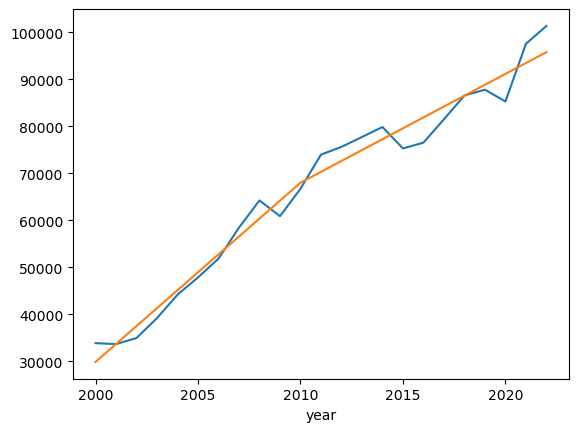

In [19]:
ok_gdp.plot()
plt.plot(ok_gdp.year, model(ok_gdp.year, 3809.4, 2313.15, c = 67996.2, breakpoint_year=2010))

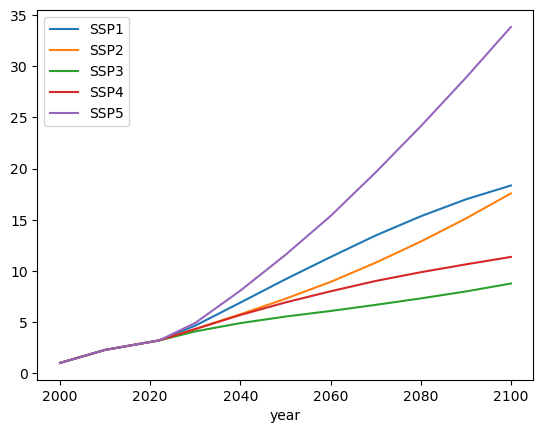

In [20]:
all_scen = []

for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    mismatch = gdp_scen[ssp].sel(year = 2022) - gdp_fit.sel(year = 2022)

    fitto = xr.concat([gdp_fit, gdp_scen[ssp].sel(year = slice(2023, None))-mismatch.values], dim = 'year')
    (fitto/fitto.sel(year = 2000)).plot(label = ssp)

    all_scen.append(fitto/fitto.sel(year = 2000))

plt.legend()

### FIT with Y scenario

In [21]:
obs2 = lef.define_obs(['E', 'Eg_ratio', 'Ig_ratio'], year_ref = year_ini)
obs_weights2 = {'E': 1, 'Eg_ratio': 10, 'Ig_ratio': 1}

In [22]:
#parnames = ['growth', 'delta_sig', 'beta_0', 'r_inv', 'a', 'b', 'gamma_g']#, 'eta_g', 'gamma_g']
parnames = ['eps', 'delta_sig', 'beta_0', 'r_inv', 'a', 'b', 'gamma_g', 'eta_g']
same_costs = True
params_prime_range['eps'] = (0.2, 0.6)
bounds = [params_prime_range[par] for par in parnames]

In [23]:
params_fit = params_prime.copy()
params_fit['eta_g'] = 0.2
params_fit['eta_f'] = 0.2
params_fit['eps'] = 0.33
scale_costs = True
same_price = True
recalc_inicond = True

inicond_recalc = inicond.copy()

### THE FIT

In [137]:
scen = all_scen[1] # SSP2
resu = dual_annealing(lef.cost_function, bounds, args = (parnames, params_fit, year_ini, inicond_recalc, verbose, obs2, obs_weights2, public_investment, mu_scen, same_costs, scale_costs, same_price, recalc_inicond, None, 'custom', scen))
print(f'AAAAAAAAAAAAAAA dual: {resu.fun:5.2f}  ', resu.x)

Cost:  0.15001563575036553 params:  {'growth': 0.01, 'eps': 0.2705364584539493, 'a': 0.8393761272665891, 'b': 0.5539394789062605, 'gamma_f': 0.5307562170907933, 'gamma_g': 0.5307562170907933, 'eta_g': 0.2940756071764507, 'eta_f': 0.2940756071764507, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.22724614094712128, 'beta_0': -0.47964470037514967, 'delta_sig': 0.648008686879091, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
Cost:  0.15001565755579083 params:  {'growth': 0.01, 'eps': 0.2705364684539493, 'a': 0.8393761272665891, 'b': 0.5539394789062605, 'gamma_f': 0.5307562170907933, 'gamma_g': 0.5307562170907933, 'eta_g': 0.2940756071764507, 'eta_f': 0.2940756071764507, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.22724614094712128, 'beta_0': -0.47964470037514967, 'delta_sig': 0.648008686879091, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
Cost:  0.15001565967825461 params:  {'growth': 0.01, 'eps': 0.2705364584539493, 'a': 0.8393761272665891, 'b': 0.55393947

In [143]:
# OLD BEST FIT: resupars = [0.24748898, 0.42677896, 0.01171892, 0.25295436, 0.6559001,  0.72356569, 0.23620877, 0.22974182]

In [ ]:
for par, parval in zip(parnames, resu.x):
    params_fit[par] = parval
    
if same_price: params_fit['gamma_f'] = params_fit['gamma_g']
if same_costs: params_fit['eta_f'] = params_fit['eta_g']

inicond_recalc = lef.inicond_yr(year_ini, params_fit, adimensional = True, fcu = lef.fossil_capacity_util)


In [139]:
params_fit

{'growth': 0.01,
 'eps': 0.24779869047245975,
 'a': 0.8859051602768233,
 'b': 0.7753414113290877,
 'gamma_f': 0.6752910811868253,
 'gamma_g': 0.6752910811868253,
 'eta_g': 0.28536314759024856,
 'eta_f': 0.28536314759024856,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.07846047428840937,
 'beta_0': -0.02866106136893916,
 'delta_sig': 0.5736877806097394,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [140]:
inicond_recalc

{'Y_ini': 1.0,
 'Eg_ini': 0.07825325742181562,
 'Ef_ini': 0.9217467425781845,
 'E_ini': 1.0,
 'Kf_ini': 1.4860336509663032,
 'Kg_ini': 0.08833141619511893}

### Fit results should be:

In [24]:
params_fit = {'growth': 0.01,
 'eps': 0.24779869047245975,
 'a': 0.8859051602768233,
 'b': 0.7753414113290877,
 'gamma_f': 0.6752910811868253,
 'gamma_g': 0.6752910811868253,
 'eta_g': 0.28536314759024856,
 'eta_f': 0.28536314759024856,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.07846047428840937,
 'beta_0': -0.02866106136893916,
 'delta_sig': 0.5736877806097394,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [25]:
inicond_recalc = {'Y_ini': 1.0,
 'Eg_ini': 0.07825325742181562,
 'Ef_ini': 0.9217467425781845,
 'E_ini': 1.0,
 'Kf_ini': 1.4860336509663032,
 'Kg_ini': 0.08833141619511893}

### Hist and future scenarios

In [26]:
resu_allscen = []
for scen in all_scen:
    resuok = lef.run_model(inicond = inicond_recalc, params = params_fit, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=scale_costs, gdp_type='custom', gdp_scenario=scen)
    resu_allscen.append(resuok)

params:  {'growth': 0.01, 'eps': 0.24779869047245975, 'a': 0.8859051602768233, 'b': 0.7753414113290877, 'gamma_f': 0.6752910811868253, 'gamma_g': 0.6752910811868253, 'eta_g': 0.28536314759024856, 'eta_f': 0.28536314759024856, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.07846047428840937, 'beta_0': -0.02866106136893916, 'delta_sig': 0.5736877806097394, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.11     -0.66      0.08      0.92      0.01      0.44      0.00      0.03
params:  {'growth': 0.01, 'eps': 0.24779869047245975, 'a': 0.8859051602768233, 'b': 0.7753414113290877, 'gamma_f': 0.6752910811868253, 'gamma_g': 0.6752910811868253, 'eta_g': 0.28536314759024856, 'eta_f': 0.28536314759024856, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.07846047428840937, 'beta_0': -0.02866106136893916, 'delta_sig': 0.5736877806097394, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.11     -0.67      0.08      0.95      0.01      0.45      0.00 

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

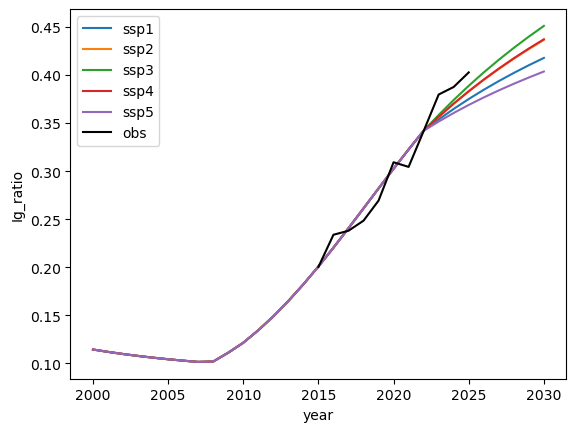

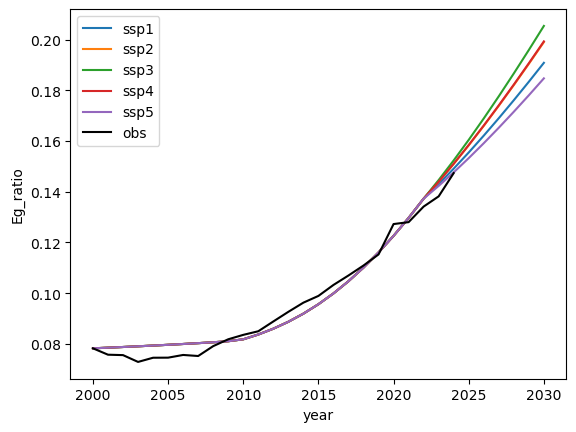

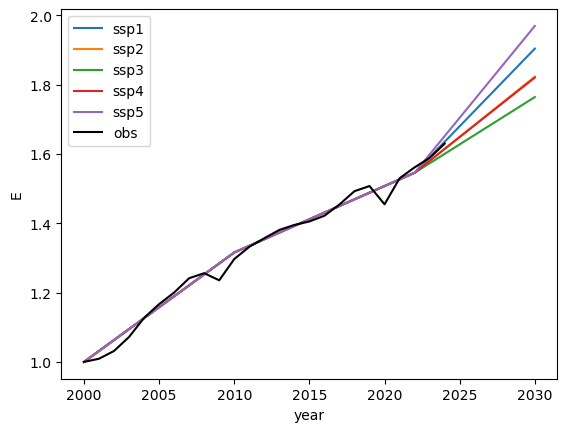

In [27]:
lef.plot_resuvsobs_ds(resu_allscen, obs2, run_names = [f'ssp{i+1}' for i in range(5)], year_ok = slice(2000, 2030))

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

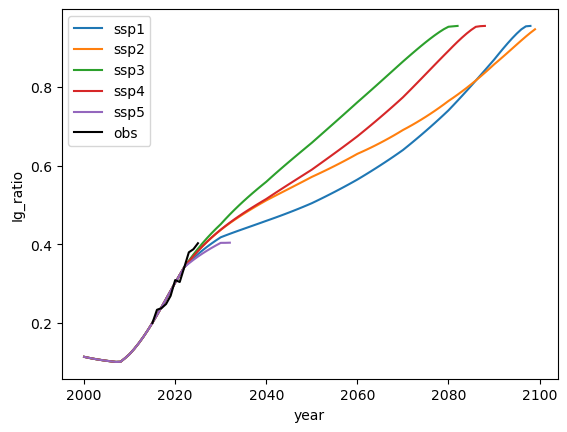

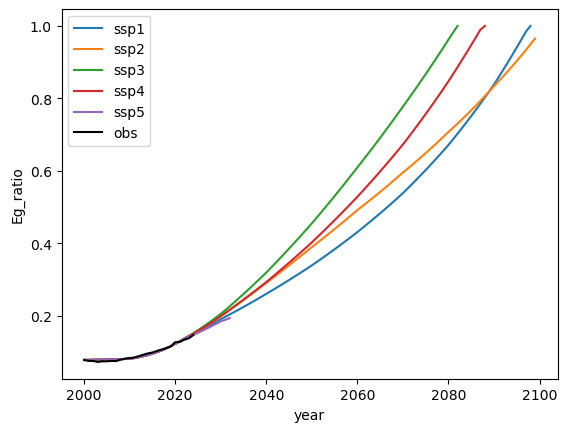

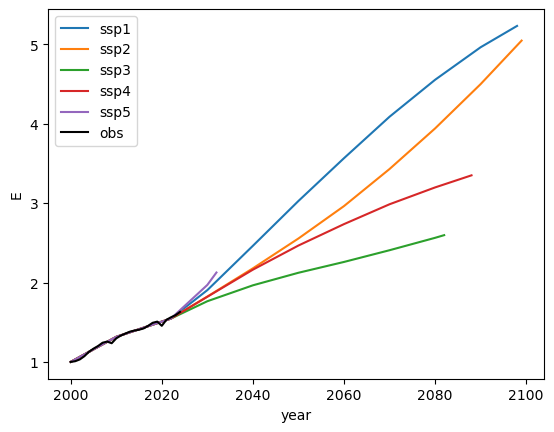

In [28]:
lef.plot_resuvsobs_ds(resu_allscen, obs2, run_names = [f'ssp{i+1}' for i in range(5)], year_ok = slice(2000, 2100))

### With growth

In [29]:
all_growths = dict()

for gro in np.arange(0., 0.06, 0.01):
    gdp_gro = []
    Y0 = gdp_fit.sel(year = 2022).values + 0.
    for i in range(2101-2023):
        Y1 = lef.GDP(Y0, growth= gro)
        gdp_gro.append(Y1)
        Y0 = Y1 + 0.

    ds = xr.DataArray(gdp_gro, coords={'year': np.arange(2023, 2101)})

    gdp_fin = xr.concat([gdp_fit, ds], dim = 'year')

    all_growths[gro] = gdp_fin


In [30]:

rainbow_palette = [
    "#D70000",  # Dark Red
    "#E56000",  # Dark Orange
    "#FFC700",  # Gold
    "#008700",  # Dark Green
    "#0057A0",  # Dark Blue
    "#4B0082"   # Indigo (Dark Purple)
]

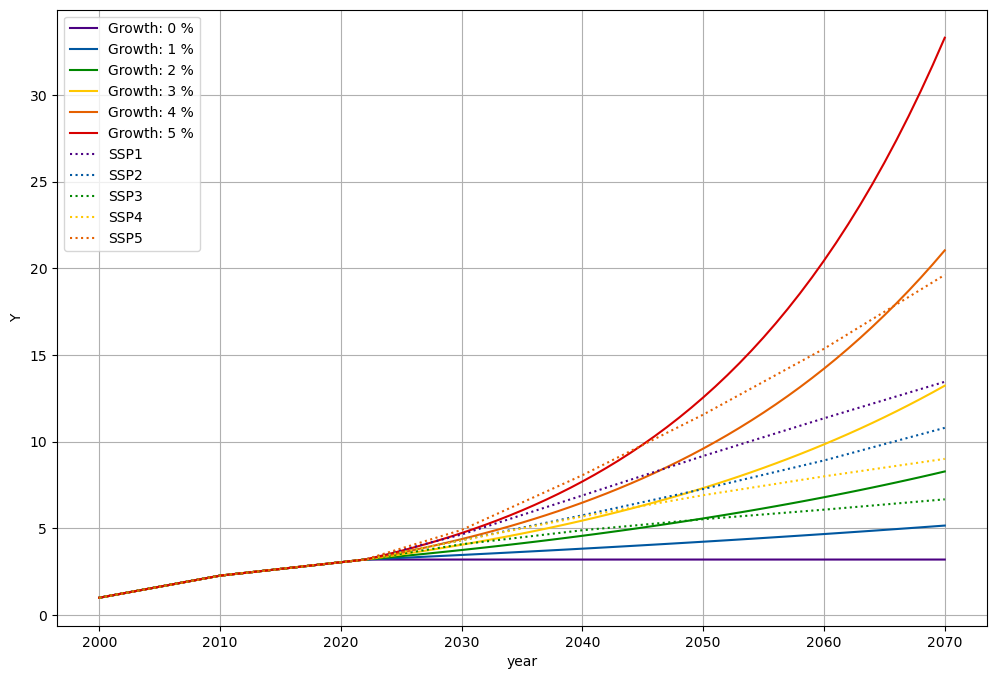

In [105]:
fig = plt.figure(figsize = (12, 8))

for gro, re, col in zip(np.arange(0., 0.06, 0.01), all_growths, rainbow_palette[::-1]):
    (all_growths[re].sel(year = slice(2000, 2070))/all_growths[re].sel(year = 2000)).plot(label = f'Growth: {int(100*gro)} %', color = col)

for i, col in zip(range(5), rainbow_palette[::-1]):
    all_scen[i].sel(year = slice(2000, 2070)).plot(label = f'SSP{i+1}', ls = ':', color = col)

plt.xlabel('year')
plt.ylabel('Y')
plt.legend()
plt.grid()

In [31]:
resu_groscen = []
for gro in np.arange(0., 0.06, 0.01):
    scen = all_growths[gro]/all_growths[gro].sel(year = 2000)
    resuok = lef.run_model(inicond = inicond_recalc, params = params_fit, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=scale_costs, gdp_type='custom', gdp_scenario=scen)
    resu_groscen.append(resuok)

params:  {'growth': 0.01, 'eps': 0.24779869047245975, 'a': 0.8859051602768233, 'b': 0.7753414113290877, 'gamma_f': 0.6752910811868253, 'gamma_g': 0.6752910811868253, 'eta_g': 0.28536314759024856, 'eta_f': 0.28536314759024856, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.07846047428840937, 'beta_0': -0.02866106136893916, 'delta_sig': 0.5736877806097394, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.11     -0.66      0.08      0.92      0.01      0.44      0.00      0.03
params:  {'growth': 0.01, 'eps': 0.24779869047245975, 'a': 0.8859051602768233, 'b': 0.7753414113290877, 'gamma_f': 0.6752910811868253, 'gamma_g': 0.6752910811868253, 'eta_g': 0.28536314759024856, 'eta_f': 0.28536314759024856, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.07846047428840937, 'beta_0': -0.02866106136893916, 'delta_sig': 0.5736877806097394, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.11     -0.67      0.08      0.95      0.01      0.45      0.00 

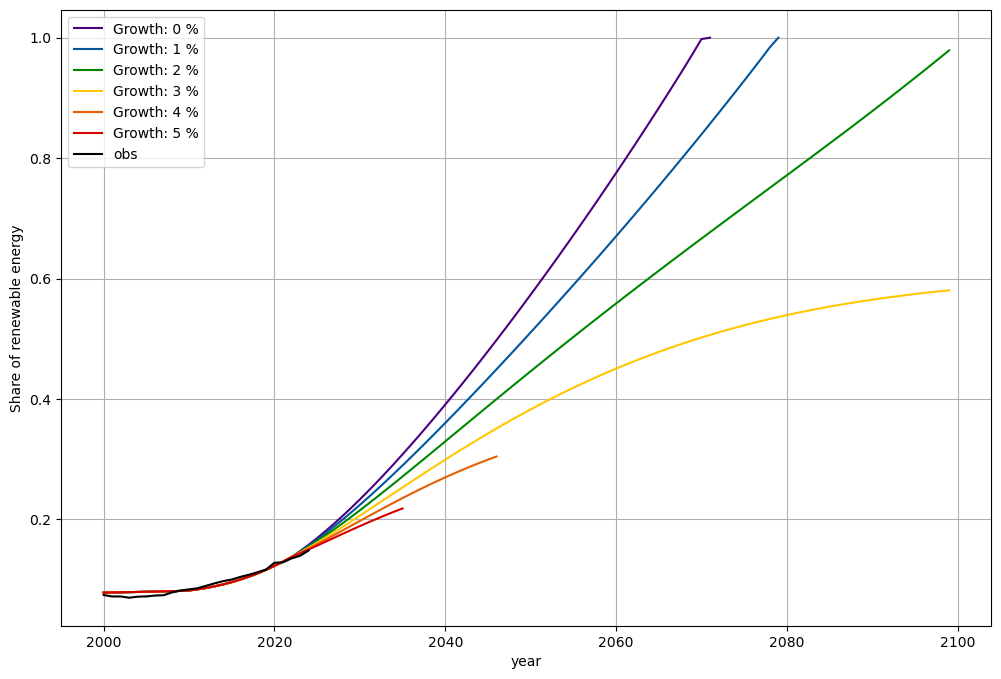

In [32]:
fig = plt.figure(figsize = (12, 8))

for gro, re, col in zip(np.arange(0., 0.06, 0.01), resu_groscen, rainbow_palette[::-1]):
    re['Eg_ratio'].plot(label = f'Growth: {int(100*gro)} %', color = col)

lef.Eg_ratio.sel(year = slice(2000, None)).plot(label = 'obs', color = 'black')

plt.xlabel('year')
plt.ylabel('Share of renewable energy')
plt.legend()
plt.grid()

In [38]:
emiss_scen = dict()

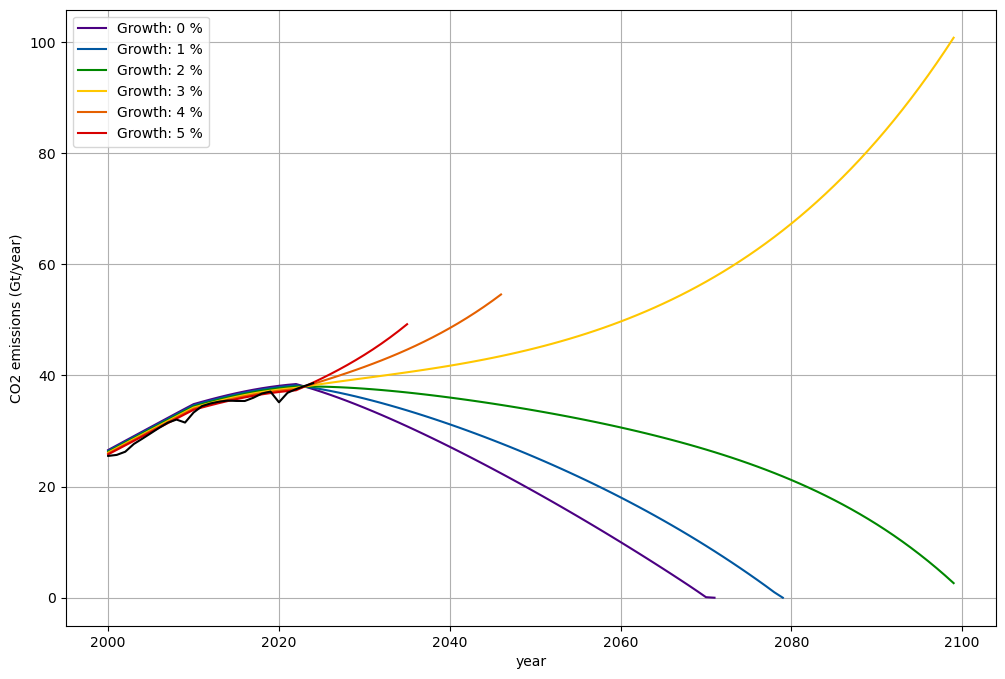

In [39]:
fig = plt.figure(figsize = (12, 8))

for gro, re, col in zip(np.arange(0., 0.06, 0.01), resu_groscen, rainbow_palette[::-1]):
    lef.to_emissions(re['Ef']).plot(label = f'Growth: {int(100*gro)} %', color = col)
    emiss_scen[gro] = lef.to_emissions(re['Ef'])

# lef.to_emissions(resu_hist['Ef']).sel(year = slice(2000, 2023)).plot(color = 'grey')
lef.co2.sel(year = slice(2000, None)).plot(color = 'black')
# lef.Eg_ratio.plot(label = 'obs', color = 'black')

plt.xlabel('year')
plt.ylabel('CO2 emissions (Gt/year)')
plt.legend()
plt.grid()

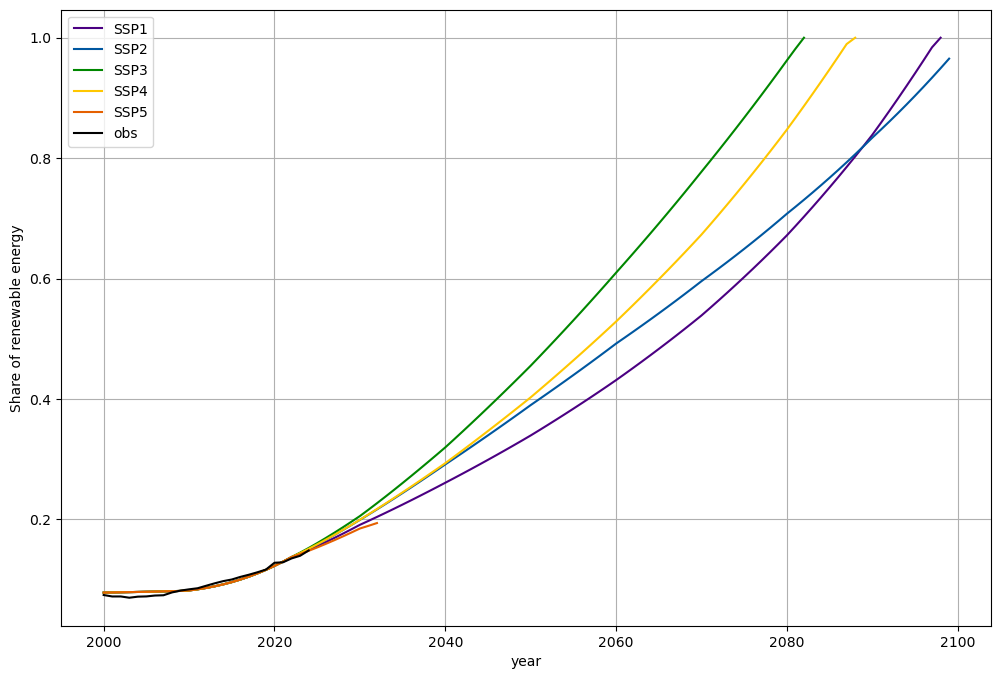

In [34]:
fig = plt.figure(figsize = (12, 8))

for ssp, re, col in zip([f'SSP{i}' for i in range(1,6)], resu_allscen, rainbow_palette[::-1]):
    re['Eg_ratio'].plot(label = ssp, color = col)

lef.Eg_ratio.sel(year = slice(2000, None)).plot(label = 'obs', color = 'black')

plt.xlabel('year')
plt.ylabel('Share of renewable energy')
plt.legend()
plt.grid()

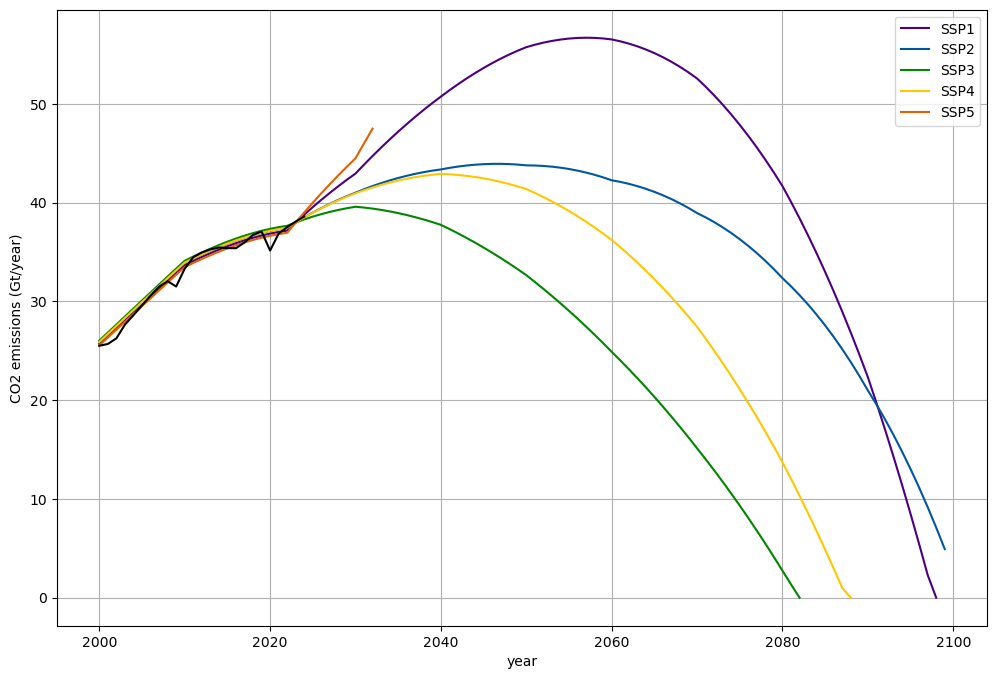

In [40]:
fig = plt.figure(figsize = (12, 8))

for ssp, re, col in zip([f'SSP{i}' for i in range(1,6)], resu_allscen, rainbow_palette[::-1]):
    lef.to_emissions(re['Ef']).plot(label = ssp, color = col)
    emiss_scen[ssp] = lef.to_emissions(re['Ef'])

# lef.to_emissions(resu_hist['Ef']).sel(year = slice(2000, 2023)).plot(color = 'grey')
lef.co2.sel(year = slice(2000, None)).plot(color = 'black')
# lef.Eg_ratio.plot(label = 'obs', color = 'black')

plt.xlabel('year')
plt.ylabel('CO2 emissions (Gt/year)')
plt.legend()
plt.grid()

In [107]:
import pickle

In [108]:
with open('results_neweq1_030326.p', 'wb') as filo:
    pickle.dump([resu_groscen, resu_allscen], filo)

## Now: convert to temperature scenarios

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import os

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties

import random

In [52]:
import fair
fair.__version__

'2.2.1'

### Create model

In [42]:
def extend_dataarray_to_2100(da, extend_to_year = 2100, time_dim = 'year'):
    """Extend a yearly DataArray to 2100 by repeating the last year's values."""
    last_year_data = da.isel({time_dim: -1})
    last_year = int(da[time_dim].values[-1])
    
    new_years = np.arange(last_year + 1, extend_to_year + 1)
    repeated = xr.concat([last_year_data] * len(new_years), dim=time_dim)
    repeated[time_dim] = new_years

    return xr.concat([da, repeated], dim=time_dim)

In [43]:
emiss_scen.keys()

dict_keys([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 'SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5'])

In [46]:
emiss_scen_ok = dict()
for ke in emiss_scen:
    if ke not in [0.04, 0.05, 'SSP5']:
        if isinstance(ke, float):
            nuke = f'gro{int(ke*100)}'
        else:
            nuke = ke
        emiss_scen_ok[nuke] = extend_dataarray_to_2100(emiss_scen[ke])

In [48]:
emiss_scen_ok.keys()

dict_keys(['gro0', 'gro1', 'gro2', 'gro3', 'SSP1', 'SSP2', 'SSP3', 'SSP4'])

In [57]:
# Define number of ensemble members
n_ens = 100
ok_config = 'central' #f.define_configs(['high', 'central', 'low'])
allscen = emiss_scen_ok.keys()
ens_names = ['ens{:03d}'.format(i) for i in range(n_ens)]

y_end = 2200
y_ini = 2023

f = FAIR()
f.define_time(1750, y_end, 1)
f.define_scenarios(allscen)
f.define_configs(['ens{:03d}'.format(i) for i in range(n_ens)])

# Select only basic species
species, properties = read_properties('fair_data/species_configs_properties.csv')
properties['CH4']['input_mode'] = 'emissions' # Set ch4 and n2o in emission mode
properties['N2O']['input_mode'] = 'emissions'
f.define_species(species, properties)

# For all species run:
# species_all, properties_all = read_properties()

# Defines the model
f.allocate()

f.fill_species_configs('fair_data/species_configs_properties.csv')

MissingDimensionsError: cannot set variable 'scenario' with 0-dimensional data without explicit dimension names. Pass a tuple of (dims, data) instead.

### Select parameters and create ensemble

In [ ]:
# Step 1: Read the existing CSV file
input_file = 'fair_data/basic_run_example/configs_ensemble.csv'  # Specify your input file name
df = pd.read_csv(input_file)

# Step 2: Extract the central sensitivity setup (high, central, low)
params = df[df.iloc[:, 0] == 'central']

random_seeds = np.array([random.randint(1, 1e7) for i in range(n_ens)])
new_data = {col: [params[col].values[0]] * n_ens if col != 'seed' else random_seeds for col in df.columns}
new_data['Unnamed: 0'] = ens_names # names
ensemble = pd.DataFrame(new_data)


if not os.path.exists('fair_data/ensemble/'): os.mkdir('fair_data/ensemble/')
output_file = f'fair_data/ensemble/configs_central_n{n_ens}.csv'  # Specify your output file name
ensemble.to_csv(output_file, index=False)

print(f"\nNew data written to {output_file}")



New data written to fair_data/ensemble/configs_central_n500.csv


In [ ]:
f.override_defaults(f'fair_data/ensemble/configs_central_n{n_ens}.csv')

### Emissions

In [ ]:
emission_all = pd.read_csv('/home/fedef/Research/git/explore-extensions/data/emissions/extensions_1750-2500.csv')

anni_hist = [('{:6.1f}'.format(i+0.5)) for i in range(1750, y_ini-1)]
print(np.unique(emission_all['scenario']))

emissions = dict()
for cos in ['CO2 FFI', 'CO2 AFOLU', 'Sulfur', 'CH4', 'N2O']:
    emissions[cos] = emission_all[(emission_all['variable'] == cos) & (emission_all['scenario'] == 'medium-overshoot')][anni_hist].values.squeeze()
    #print(emissions[cos].shape)

['high-extension' 'high-overshoot' 'low' 'medium-extension'
 'medium-overshoot' 'verylow' 'verylow-overshoot']


In [ ]:
ifut = y_end - y_ini +1

fut_emiss = dict()
fut_emiss['zero_emiss'] = np.zeros(ifut)
fut_emiss['rampdown_40'] = np.append(np.linspace(1, 0, 40), np.zeros(ifut-40))
fut_emiss['jumpramp_20'] = np.append(np.linspace(0.7, 0, 20), np.zeros(ifut-20))
fut_emiss['bau10_ramp40'] = np.append(np.append(np.ones(10), np.linspace(1, 0, 40)), np.zeros(ifut-50))
fut_emiss['bau'] = np.ones(ifut)

allscen = fut_emiss.keys()

for scen in allscen:
    for cos in ['CO2 FFI', 'CO2 AFOLU', 'Sulfur', 'CH4', 'N2O']:
        # if cos != 'CO2 FFI':
        #     f.emissions.loc[{'specie': cos, 'scenario': scen}] = np.vstack(n_ens * [np.append(emissions[cos], np.zeros(76))]).T
        # else:
        # Now all emissions are proportional to the CO2 FFI
        f.emissions.loc[{'specie': cos, 'scenario': scen}] = np.vstack(n_ens * [np.append(emissions[cos], emissions[cos][-1]*fut_emiss[scen])]).T

f.forcing.loc[{'specie': 'Volcanic'}] = 0.
# f.concentration.loc[{'specie': 'CH4'}] = 1900.
# f.concentration.loc[{'specie': 'N2O'}] = 336.

### Initialize

In [ ]:
# Define initial conditions
# from fair.interface import initialise

### Starting from present day.. doesn't work!
# initialise(f.concentration, 420, specie='CO2')
# initialise(f.concentration, 1900, specie='CH4')
# initialise(f.concentration, 336, specie='N2O')
# initialise(f.forcing, 0.7)
# initialise(f.temperature, 1.3)
# initialise(f.cumulative_emissions, 1000., specie = 'CO2') # 40.*50/2
# initialise(f.cumulative_emissions, 0., specie = 'CH4') # 40.*50/2
# initialise(f.cumulative_emissions, 0., specie = 'N2O') # 40.*50/2
# initialise(f.airborne_emissions, 140., specie = 'CO2')
# initialise(f.ocean_heat_content_change, 20e21)

In [ ]:
# Starting from pre-industrial
from fair.interface import initialise

for cos in ['CO2', 'CH4', 'N2O']:
    initialise(f.concentration, f.species_configs.loc[{'specie': cos}].baseline_concentration[0], specie=cos)

initialise(f.forcing, 0.)
initialise(f.temperature, 0.)
initialise(f.cumulative_emissions, 0.)
initialise(f.ocean_heat_content_change, 0.)

In [ ]:
f.run()

Running 2500 projections in parallel: 100%|██████████| 450/450 [00:02<00:00, 155.82timesteps/s]


In [ ]:
colors = ['steelblue', 'orange', 'forestgreen', 'indianred', 'violet']

In [ ]:
def plot_scen(istart = 2000, iend = y_end, yave = 5, do_rolling = True):
    iro = 0
    if do_rolling: iro = yave

    fig, ax = plt.subplots(figsize = (16,9))
    for scen, col in zip(list(allscen)[::-1], colors[::-1]):
        mean = f.temperature.sel(scenario = scen, layer = 0, timebounds = slice(y_ini-iro, iend+iro)).mean(['config'])
        std = f.temperature.sel(scenario = scen, layer = 0, timebounds = slice(y_ini-iro, iend+iro)).std(['config'])
        if do_rolling:
            mean = mean.rolling(timebounds = yave, min_periods=yave//2, center=True).mean().sel(timebounds = slice(y_ini, iend))
            std = std.rolling(timebounds = yave, min_periods=yave//2, center=True).mean().sel(timebounds = slice(y_ini, iend))

        ax.fill_between(f.temperature.timebounds.sel(timebounds = slice(y_ini, iend)), mean-std, mean+std, color = col, alpha=0.3, edgecolor = 'none')
        ax.plot(f.temperature.timebounds.sel(timebounds = slice(y_ini, iend)), mean, color = col, lw = 3, label = scen)

    mean = f.temperature.sel(layer = 0, timebounds = slice(istart-iro, y_ini+1+iro)).mean(['config', 'scenario'])
    std = f.temperature.sel(layer = 0, timebounds = slice(istart-iro, y_ini+1+iro)).std(['config', 'scenario'])
    if do_rolling:
        mean = mean.rolling(timebounds = yave, min_periods=yave//2, center=True).mean().sel(timebounds = slice(istart, y_ini+1))
        std = std.rolling(timebounds = yave, min_periods=yave//2, center=True).mean().sel(timebounds = slice(istart, y_ini+1))

    col = 'grey'
    ax.fill_between(f.temperature.timebounds.sel(timebounds = slice(istart,y_ini+1)), mean-std, mean+std, color = col, alpha=0.1, edgecolor = 'none')
    ax.plot(f.temperature.timebounds.sel(timebounds = slice(istart,y_ini+1)), mean, label = 'hist', color = col, lw = 3)

    ax.axhline(1.5, color = 'red', ls = ':', lw = 0.5)
    #plt.title('Temperature change')
    plt.xlabel('year')
    plt.ylabel('Temperature anomaly (K)')
    plt.legend()
    plt.grid(color='gray', linestyle=':', linewidth=0.5)    
    plt.savefig(f'future_noemiss_bau_{istart}-{iend}.pdf')

    return

def plot_scen_vs_refscen(refscen, istart = 2025, iend = y_end, yave = 5, do_rolling = True):
    iro = 0
    if do_rolling: iro = yave

    fig, ax = plt.subplots(figsize = (16,9))
    col = 'violet'
    
    refmean = f.temperature.sel(scenario = refscen, layer = 0, timebounds = slice(y_ini-iro, iend+iro)).mean(['config'])
    refstd = f.temperature.sel(scenario = refscen, layer = 0, timebounds = slice(y_ini-iro, iend+iro)).std(['config'])
    if do_rolling:
        refmean = refmean.rolling(timebounds = yave, min_periods=yave//2, center=True).mean().sel(timebounds = slice(y_ini, iend))
        refstd = refstd.rolling(timebounds = yave, min_periods=yave//2, center=True).mean().sel(timebounds = slice(y_ini, iend))
    
    ax.fill_between(f.temperature.timebounds.sel(timebounds = slice(y_ini, iend)), -refstd, refstd, color = col, alpha=0.3, edgecolor = 'none')

    for scen, col in zip(list(allscen)[::-1], colors[::-1]):
        mean = f.temperature.sel(scenario = scen, layer = 0, timebounds = slice(y_ini-iro, iend+iro)).mean(['config'])
        # std = f.temperature.sel(scenario = scen, layer = 0, timebounds = slice(y_ini-iro, iend+iro)).std(['config'])
        if do_rolling:
            mean = mean.rolling(timebounds = yave, min_periods=yave//2, center=True).mean().sel(timebounds = slice(y_ini, iend))
            # std = std.rolling(timebounds = yave, min_periods=yave//2, center=True).mean().sel(timebounds = slice(y_ini, iend))

        ax.plot(f.temperature.timebounds.sel(timebounds = slice(y_ini, iend)), mean-refmean, color = col, lw = 3, label = scen)

    # mean = f.temperature.sel(layer = 0, timebounds = slice(istart-iro, y_ini+1+iro)).mean(['config', 'scenario'])
    # std = f.temperature.sel(layer = 0, timebounds = slice(istart-iro, y_ini+1+iro)).std(['config', 'scenario'])
    # if do_rolling:
    #     mean = mean.rolling(timebounds = yave, min_periods=yave//2, center=True).mean().sel(timebounds = slice(istart, y_ini+1))
    #     std = std.rolling(timebounds = yave, min_periods=yave//2, center=True).mean().sel(timebounds = slice(istart, y_ini+1))

    # col = 'grey'
    # ax.fill_between(f.temperature.timebounds.sel(timebounds = slice(istart,y_ini+1)), mean-std, mean+std, color = col, alpha=0.1, edgecolor = 'none')
    # ax.plot(f.temperature.timebounds.sel(timebounds = slice(istart,y_ini+1)), mean, label = 'hist', color = col, lw = 3)

    # ax.axhline(1.5, color = 'red', ls = ':', lw = 0.5)
    #plt.title('Temperature change')
    plt.xlabel('year')
    plt.ylabel('Temperature anomaly (K)')
    plt.legend()
    plt.grid(color='gray', linestyle=':', linewidth=0.5)    
    plt.savefig(f'future_tempanom_{istart}-{iend}.pdf')

    return

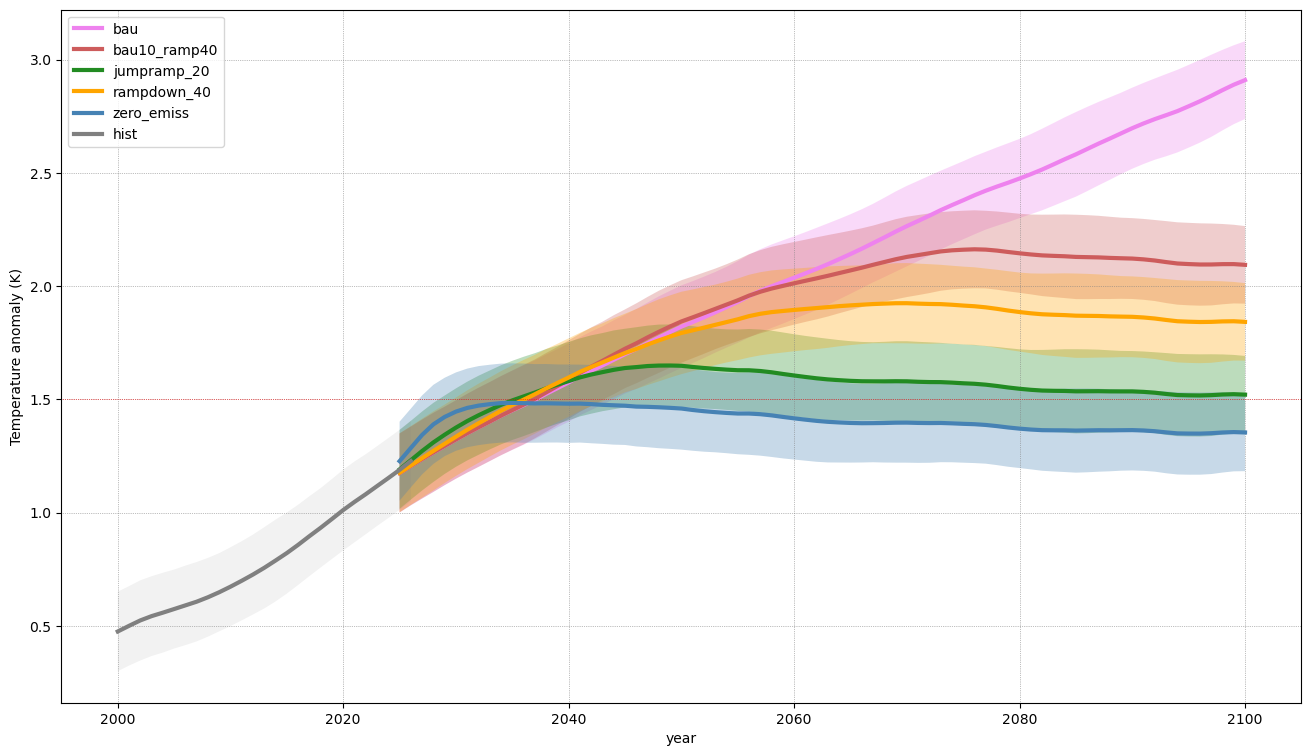

In [ ]:
istart = 2000
iend = 2100
yave = 5
do_rolling = True

plot_scen(istart, iend, yave, do_rolling)